In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation
import warnings
warnings.filterwarnings('ignore')

# Set style for better plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
import os
data_path = '../data/raw/'
files = os.listdir(data_path)
print("Files in data/raw:", files)

# Load the analyst ratings CSV 
news_df = pd.read_csv('../data/raw/raw_analyst_ratings.csv')

print(f"\nLoaded {len(news_df):,} news articles")
print(f"Columns: {news_df.columns.tolist()}")
print("\nFirst 5 rows:")
print(news_df.head())

Files in data/raw: ['AAPL.csv', 'AMZN.csv', 'GOOG.csv', 'META.csv', 'NVDA.csv', 'raw_analyst_ratings.csv']

Loaded 1,407,328 news articles
Columns: ['Unnamed: 0', 'headline', 'url', 'publisher', 'date', 'stock']

First 5 rows:
   Unnamed: 0                                           headline  \
0           0            Stocks That Hit 52-Week Highs On Friday   
1           1         Stocks That Hit 52-Week Highs On Wednesday   
2           2                      71 Biggest Movers From Friday   
3           3       46 Stocks Moving In Friday's Mid-Day Session   
4           4  B of A Securities Maintains Neutral on Agilent...   

                                                 url          publisher  \
0  https://www.benzinga.com/news/20/06/16190091/s...  Benzinga Insights   
1  https://www.benzinga.com/news/20/06/16170189/s...  Benzinga Insights   
2  https://www.benzinga.com/news/20/05/16103463/7...         Lisa Levin   
3  https://www.benzinga.com/news/20/05/16095921/4...         Lis

In [3]:
#Basic data information
print("Dataset Info:")
print(news_df.info())
print("\nMissing Values:")
print(news_df.isnull().sum())

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 1407328 entries, 0 to 1407327
Data columns (total 6 columns):
 #   Column      Non-Null Count    Dtype
---  ------      --------------    -----
 0   Unnamed: 0  1407328 non-null  int64
 1   headline    1407328 non-null  str  
 2   url         1407328 non-null  str  
 3   publisher   1407328 non-null  str  
 4   date        1407328 non-null  str  
 5   stock       1407328 non-null  str  
dtypes: int64(1), str(5)
memory usage: 64.4 MB
None

Missing Values:
Unnamed: 0    0
headline      0
url           0
publisher     0
date          0
stock         0
dtype: int64


HEADLINE LENGTH STATISTICS
Average headline length: 73.1 characters
Median headline length: 64.0 characters
Shortest headline: 3 characters
Longest headline: 512 characters


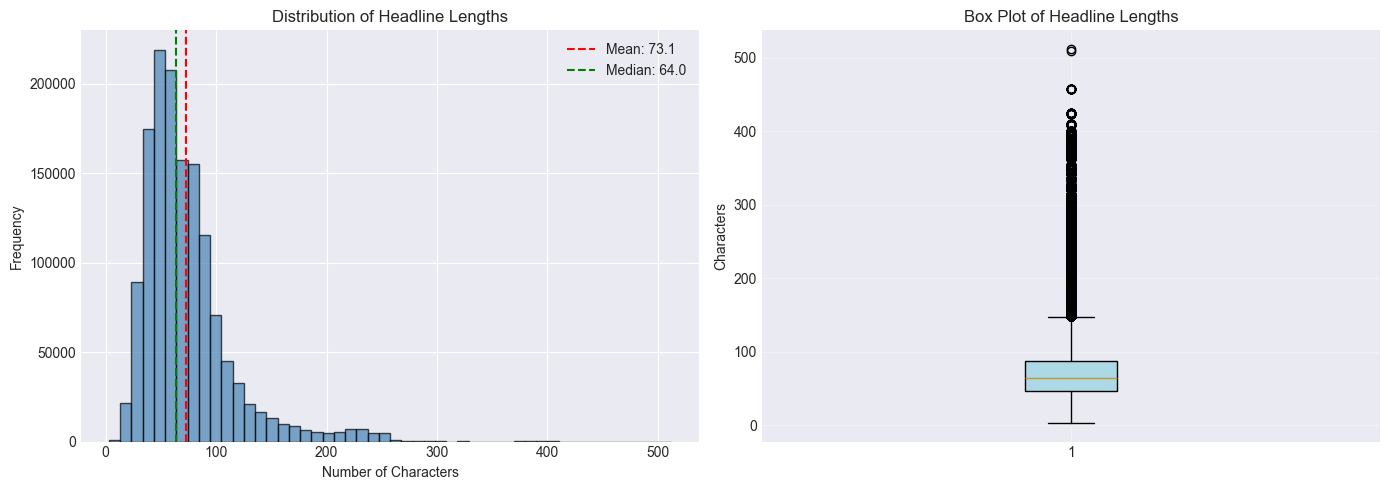

In [4]:
#Descriptive Statistics - Headline Lengths
news_df['headline_length'] = news_df['headline'].str.len()

print("="*50)
print("HEADLINE LENGTH STATISTICS")
print("="*50)
print(f"Average headline length: {news_df['headline_length'].mean():.1f} characters")
print(f"Median headline length: {news_df['headline_length'].median():.1f} characters")
print(f"Shortest headline: {news_df['headline_length'].min()} characters")
print(f"Longest headline: {news_df['headline_length'].max()} characters")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(news_df['headline_length'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(news_df['headline_length'].mean(), color='red', linestyle='--', label=f'Mean: {news_df["headline_length"].mean():.1f}')
axes[0].axvline(news_df['headline_length'].median(), color='green', linestyle='--', label=f'Median: {news_df["headline_length"].median():.1f}')
axes[0].set_title('Distribution of Headline Lengths')
axes[0].set_xlabel('Number of Characters')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Box plot
box = axes[1].boxplot(news_df['headline_length'], vert=True, patch_artist=True)
box['boxes'][0].set_facecolor('lightblue')
axes[1].set_title('Box Plot of Headline Lengths')
axes[1].set_ylabel('Characters')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

PUBLISHER ANALYSIS
Total unique publishers: 1034

Top 10 Most Active Publishers:
publisher
Paul Quintaro        228373
Lisa Levin           186979
Benzinga Newsdesk    150484
Charles Gross         96732
Monica Gerson         82380
Eddie Staley          57254
Hal Lindon            49047
ETF Professor         28489
Juan Lopez            28438
Benzinga Staff        28114
Name: count, dtype: int64


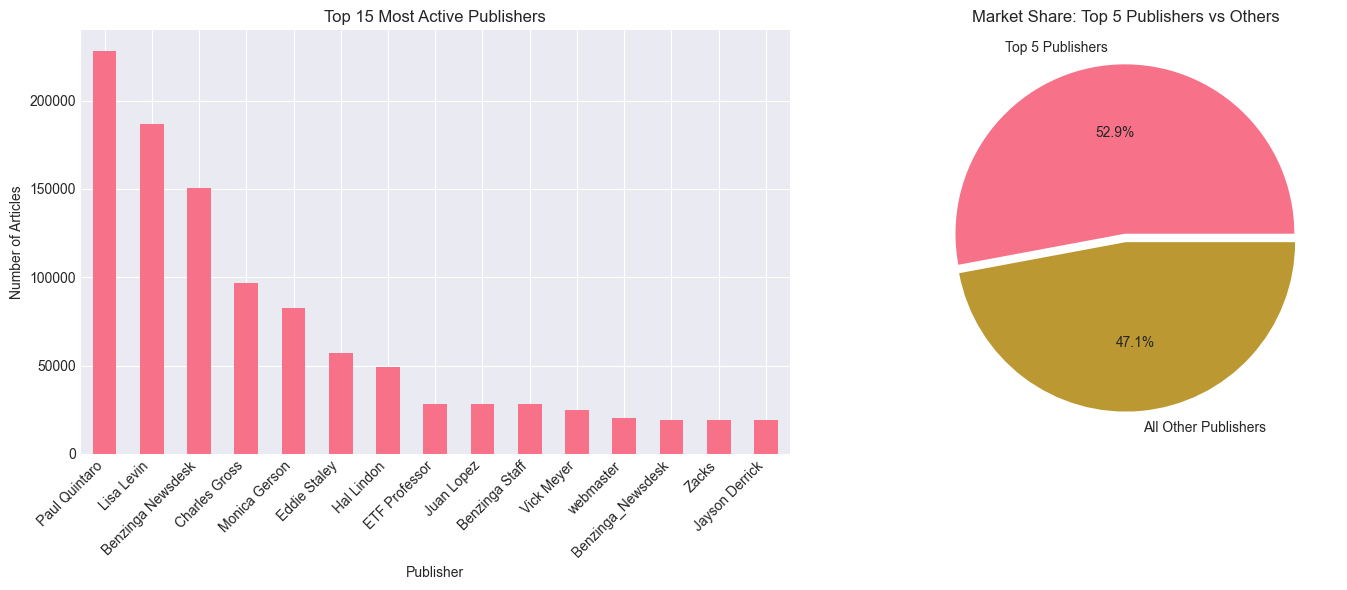

In [6]:
#Publisher Analysis
publisher_counts = news_df['publisher'].value_counts()

print("="*50)
print("PUBLISHER ANALYSIS")
print("="*50)
print(f"Total unique publishers: {news_df['publisher'].nunique()}")
print(f"\nTop 10 Most Active Publishers:")
print(publisher_counts.head(10))

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Bar chart
publisher_counts.head(15).plot(kind='bar', ax=axes[0])
axes[0].set_title('Top 15 Most Active Publishers')
axes[0].set_xlabel('Publisher')
axes[0].set_ylabel('Number of Articles')
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=45, ha='right')

# Pie chart
top5_sum = publisher_counts.head(5).sum()
others_sum = publisher_counts[5:].sum()
pie_data = pd.Series([top5_sum, others_sum], index=['Top 5 Publishers', 'All Other Publishers'])
axes[1].pie(pie_data, labels=pie_data.index, autopct='%1.1f%%', explode=(0.05, 0))
axes[1].set_title('Market Share: Top 5 Publishers vs Others')

plt.tight_layout()
plt.show()

TIME SERIES ANALYSIS
Date range: 2009-02-14 00:00:00+00:00 to 2020-06-11 21:12:35+00:00
Average daily articles: 355.8
Peak day: 2020-03-12 (2739 articles)


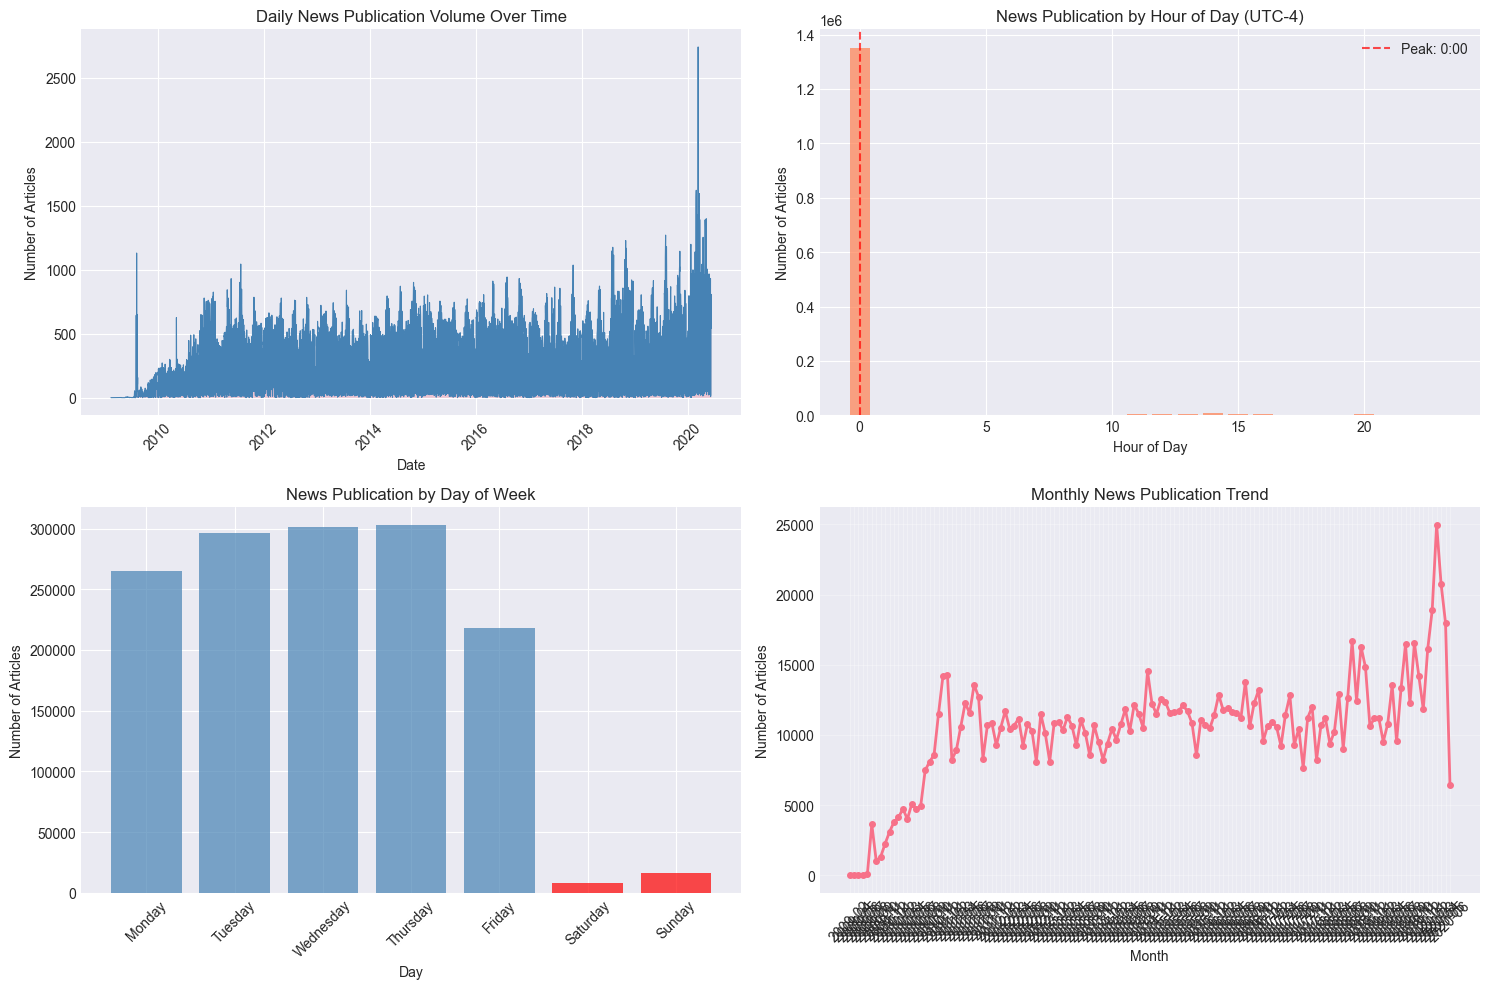

In [9]:
#Time Series Analysis
news_df['date'] = pd.to_datetime(news_df['date'], format='mixed', utc=True)

# Extract date components
news_df['publish_date'] = news_df['date'].dt.date
news_df['publish_hour'] = news_df['date'].dt.hour
news_df['publish_dayofweek'] = news_df['date'].dt.dayofweek
news_df['publish_weekday_name'] = news_df['date'].dt.day_name()

# Daily volume
daily_volume = news_df.groupby('publish_date').size()

print("="*50)
print("TIME SERIES ANALYSIS")
print("="*50)
print(f"Date range: {news_df['date'].min()} to {news_df['date'].max()}")
print(f"Average daily articles: {daily_volume.mean():.1f}")
print(f"Peak day: {daily_volume.idxmax()} ({daily_volume.max()} articles)")

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Daily volume over time
axes[0,0].plot(daily_volume.index, daily_volume.values, linewidth=0.8, color='steelblue')
axes[0,0].fill_between(daily_volume.index, daily_volume.values, alpha=0.3)
axes[0,0].set_title('Daily News Publication Volume Over Time')
axes[0,0].set_xlabel('Date')
axes[0,0].set_ylabel('Number of Articles')
plt.setp(axes[0,0].xaxis.get_majorticklabels(), rotation=45)

# Hourly distribution
hourly_dist = news_df['publish_hour'].value_counts().sort_index()
axes[0,1].bar(hourly_dist.index, hourly_dist.values, alpha=0.7, color='coral')
axes[0,1].set_title('News Publication by Hour of Day (UTC-4)')
axes[0,1].set_xlabel('Hour of Day')
axes[0,1].set_ylabel('Number of Articles')
axes[0,1].axvline(x=hourly_dist.idxmax(), color='red', linestyle='--', alpha=0.7, label=f'Peak: {hourly_dist.idxmax()}:00')
axes[0,1].legend()

# Day of week
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_dist = news_df['publish_weekday_name'].value_counts()
dow_dist = dow_dist.reindex(days_order)
colors_dow = ['red' if day in ['Saturday', 'Sunday'] else 'steelblue' for day in days_order]
axes[1,0].bar(dow_dist.index, dow_dist.values, color=colors_dow, alpha=0.7)
axes[1,0].set_title('News Publication by Day of Week')
axes[1,0].set_xlabel('Day')
axes[1,0].set_ylabel('Number of Articles')
plt.setp(axes[1,0].xaxis.get_majorticklabels(), rotation=45)

# Monthly trend
monthly_volume = news_df.groupby(news_df['date'].dt.to_period('M')).size()
axes[1,1].plot(monthly_volume.index.astype(str), monthly_volume.values, marker='o', linewidth=2, markersize=4)
axes[1,1].set_title('Monthly News Publication Trend')
axes[1,1].set_xlabel('Month')
axes[1,1].set_ylabel('Number of Articles')
plt.setp(axes[1,1].xaxis.get_majorticklabels(), rotation=45)
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

STOCK SYMBOL ANALYSIS
Total unique stocks mentioned: 6204

Top 10 Most Mentioned Stocks:
stock
MRK     3333
MS      3238
NVDA    3146
MU      3142
QQQ     3106
NFLX    3028
M       3025
EBAY    3018
GILD    2968
VZ      2966
Name: count, dtype: int64


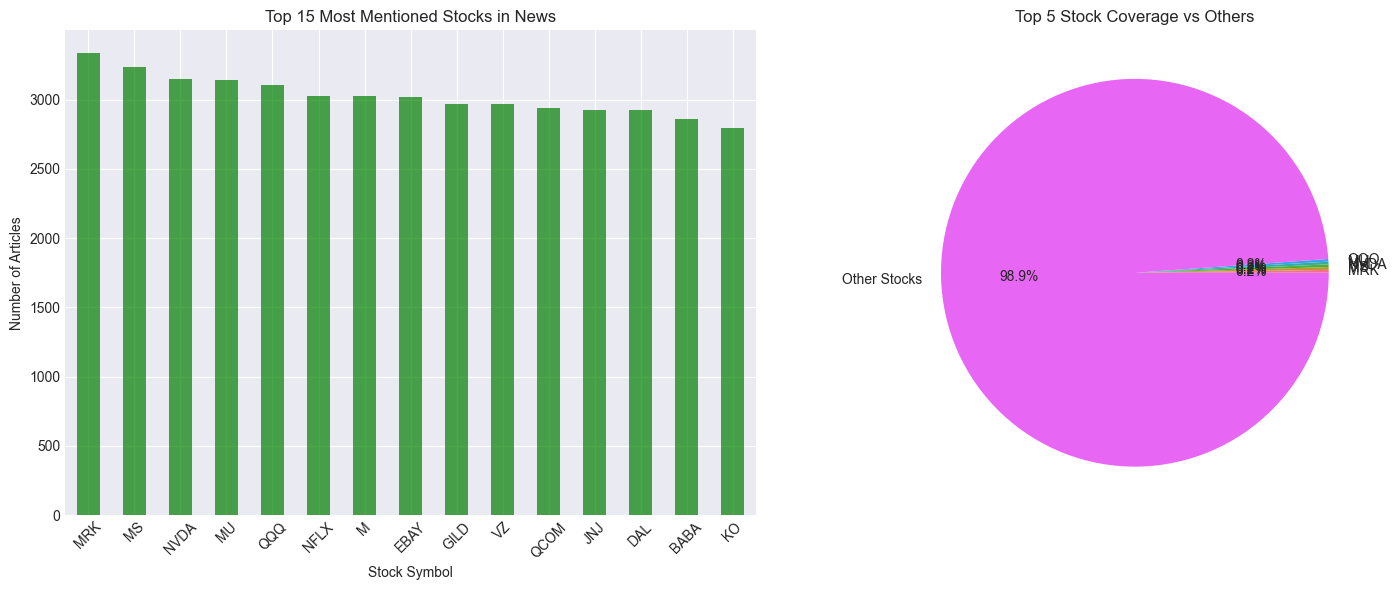

In [10]:
#Stock Symbol Analysis
stock_counts = news_df['stock'].value_counts()

print("="*50)
print("STOCK SYMBOL ANALYSIS")
print("="*50)
print(f"Total unique stocks mentioned: {news_df['stock'].nunique()}")
print(f"\nTop 10 Most Mentioned Stocks:")
print(stock_counts.head(10))

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Bar chart
stock_counts.head(15).plot(kind='bar', ax=axes[0], color='green', alpha=0.7)
axes[0].set_title('Top 15 Most Mentioned Stocks in News')
axes[0].set_xlabel('Stock Symbol')
axes[0].set_ylabel('Number of Articles')
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=45)

# Pie chart
top5_stocks = stock_counts.head(5)
others = pd.Series([stock_counts[5:].sum()], index=['Other Stocks'])
pie_stock_data = pd.concat([top5_stocks, others])
axes[1].pie(pie_stock_data, labels=pie_stock_data.index, autopct='%1.1f%%')
axes[1].set_title('Top 5 Stock Coverage vs Others')

plt.tight_layout()
plt.show()

KEYWORD EXTRACTION
Top 20 Most Common Keywords in Headlines:
   keyword  count
        vs 162099
    stocks 161776
       est 140604
       eps 128897
    market 120558
    shares 114313
   reports 108710
    update  91723
  earnings  87399
     sales  79645
  benzinga  74516
        pt  73068
      week  69572
 announces  66591
     price  64407
       buy  64371
       mid  62263
downgrades  61959
   trading  61182
    raises  57802


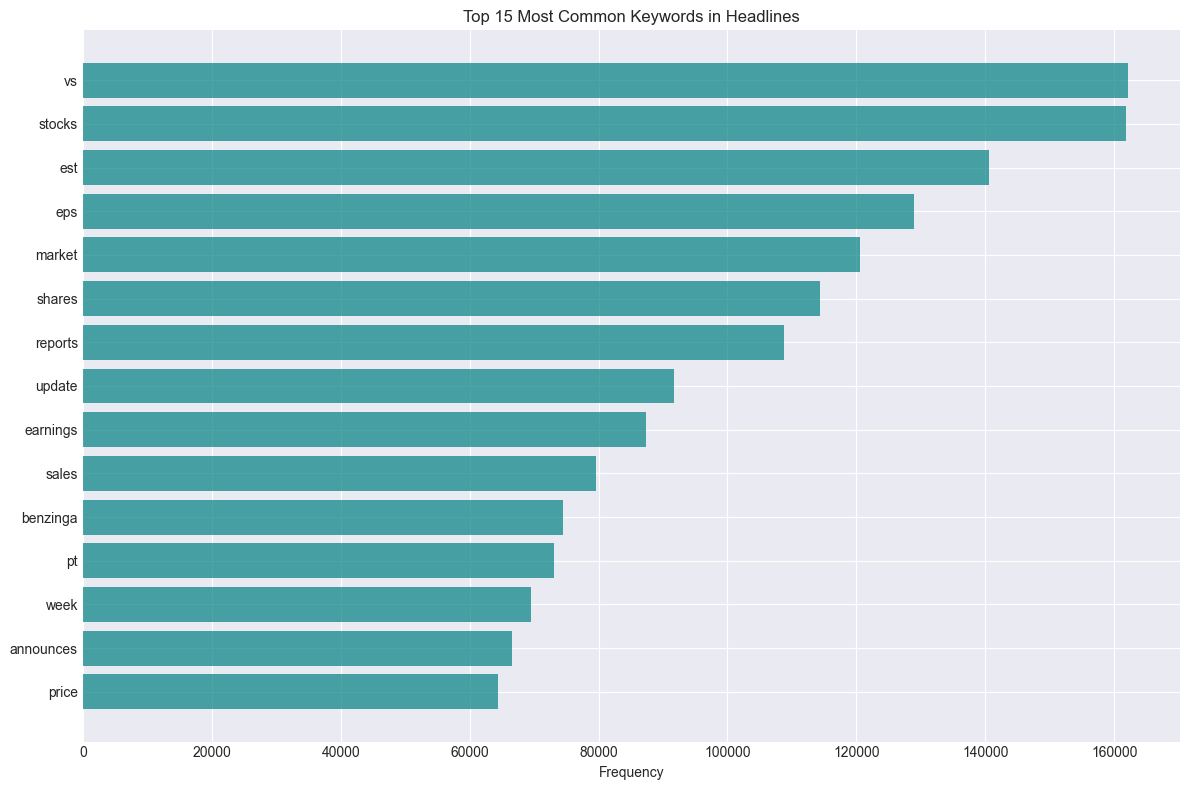

In [11]:
#Keyword Extraction with CountVectorizer
print("="*50)
print("KEYWORD EXTRACTION")
print("="*50)

vectorizer = CountVectorizer(stop_words='english', max_features=20)
X = vectorizer.fit_transform(news_df['headline'])
feature_names = vectorizer.get_feature_names_out()
word_counts = X.toarray().sum(axis=0)

keywords_df = pd.DataFrame({'keyword': feature_names, 'count': word_counts})
keywords_df = keywords_df.sort_values('count', ascending=False)

print("Top 20 Most Common Keywords in Headlines:")
print(keywords_df.to_string(index=False))

plt.figure(figsize=(12, 8))
plt.barh(keywords_df['keyword'].head(15), keywords_df['count'].head(15), color='teal', alpha=0.7)
plt.title('Top 15 Most Common Keywords in Headlines')
plt.xlabel('Frequency')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

TF-IDF ANALYSIS
Top 20 Most Important Terms by TF-IDF:
      term   tfidf_score
    stocks 120048.420657
    market  83037.704493
    shares  77559.971297
  earnings  75181.331827
        vs  65464.128259
   reports  64127.172118
    update  63627.866238
  benzinga  62142.509181
       eps  61187.454960
 announces  55964.729030
      week  55357.341471
       est  53595.025097
        pt  50750.846783
downgrades  49541.715976
     price  48214.325506
       buy  47506.387748
     sales  46230.892980
   trading  43668.171643
       mid  42797.117879
    raises  39975.413665


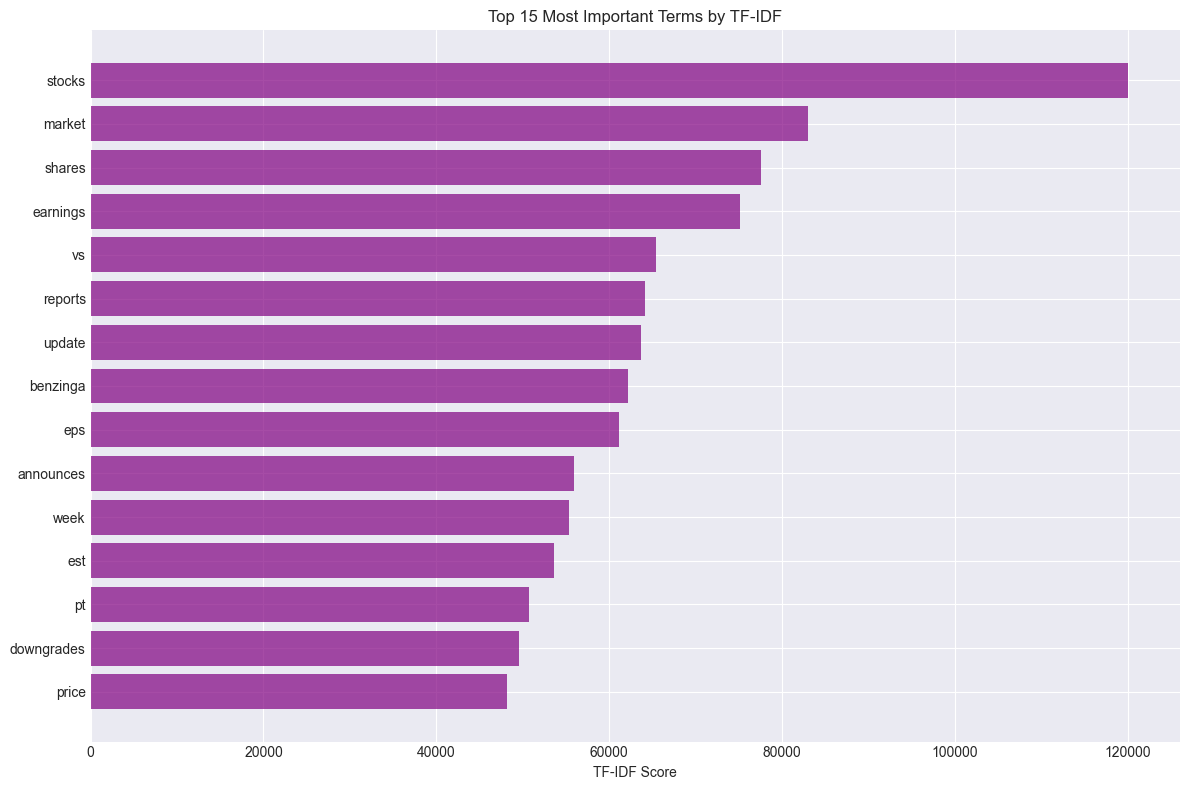

In [12]:
#TF-IDF Analysis
print("="*50)
print("TF-IDF ANALYSIS")
print("="*50)

tfidf_vectorizer = TfidfVectorizer(stop_words='english', max_features=20)
tfidf_matrix = tfidf_vectorizer.fit_transform(news_df['headline'])
tfidf_scores = tfidf_matrix.sum(axis=0).A1
tfidf_features = tfidf_vectorizer.get_feature_names_out()

tfidf_df = pd.DataFrame({'term': tfidf_features, 'tfidf_score': tfidf_scores})
tfidf_df = tfidf_df.sort_values('tfidf_score', ascending=False)

print("Top 20 Most Important Terms by TF-IDF:")
print(tfidf_df.to_string(index=False))

plt.figure(figsize=(12, 8))
plt.barh(tfidf_df['term'].head(15), tfidf_df['tfidf_score'].head(15), color='purple', alpha=0.7)
plt.title('Top 15 Most Important Terms by TF-IDF')
plt.xlabel('TF-IDF Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

RECURRING THEMES IN HEADLINES

Identified Recurring Themes in Headlines:
          Theme  Frequency
  Price Targets     257706
       Earnings     204635
Market Movement      75152


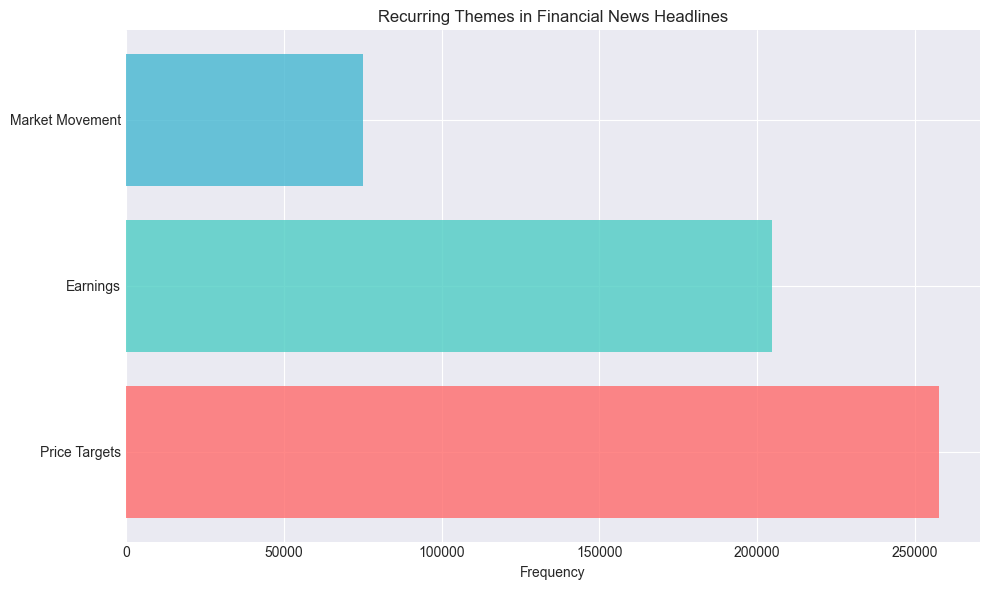

In [5]:
#Topic Modeling - Simple Keyword Co-occurrence Approach
print("="*50)
print("RECURRING THEMES IN HEADLINES")
print("="*50)

# Extract keywords and identify themes manually (fast & simple)
from collections import Counter
import re

# Define key financial themes
themes = {
    'Earnings': ['earnings', 'beat', 'miss', 'guidance', 'revenue', 'profit'],
    'Price Targets': ['price target', 'target', 'upgrade', 'downgrade', 'rating'],
    'Market Movement': ['surge', 'plunge', 'jump', 'fall', 'rally', 'decline', 'gain', 'loss']
}

# Count theme occurrences
theme_counts = {}
for theme_name, keywords in themes.items():
    count = 0
    for keyword in keywords:
        count += news_df['headline'].str.lower().str.contains(keyword, na=False).sum()
    theme_counts[theme_name] = count

# Display results
print("\nIdentified Recurring Themes in Headlines:")
theme_df = pd.DataFrame(list(theme_counts.items()), columns=['Theme', 'Frequency'])
theme_df = theme_df.sort_values('Frequency', ascending=False)
print(theme_df.to_string(index=False))

# Visualization
plt.figure(figsize=(10, 6))
plt.barh(theme_df['Theme'], theme_df['Frequency'], color=['#FF6B6B', '#4ECDC4', '#45B7D1'], alpha=0.8)
plt.title('Recurring Themes in Financial News Headlines')
plt.xlabel('Frequency')
plt.tight_layout()
plt.show()

In [11]:
# Self-contained Summary Report - Calculate all variables if needed
print("="*60)
print("KEY INSIGHTS (Calculated from your data)")
print("="*60)

# Ensure date is datetime
if not pd.api.types.is_datetime64_any_dtype(news_df['date']):
    news_df['date'] = pd.to_datetime(news_df['date'], format='mixed', utc=True)

# Ensure headline_length exists
if 'headline_length' not in news_df.columns:
    news_df['headline_length'] = news_df['headline'].str.len()

# Ensure time components exist
if 'publish_hour' not in news_df.columns:
    news_df['publish_hour'] = news_df['date'].dt.hour
if 'publish_dayofweek' not in news_df.columns:
    news_df['publish_dayofweek'] = news_df['date'].dt.dayofweek

# Calculate distributions
hourly_dist = news_df['publish_hour'].value_counts().sort_index()
stock_counts = news_df['stock'].value_counts()
publisher_counts = news_df['publisher'].value_counts()
daily_volume = news_df.groupby(news_df['date'].dt.date).size()

# TF-IDF and Keywords for Insight 4
if 'keywords_df' not in dir() or keywords_df.empty:
    vectorizer = CountVectorizer(stop_words='english', max_features=20)
    X = vectorizer.fit_transform(news_df['headline'])
    feature_names = vectorizer.get_feature_names_out()
    word_counts = X.toarray().sum(axis=0)
    keywords_df = pd.DataFrame({'keyword': feature_names, 'count': word_counts})
    keywords_df = keywords_df.sort_values('count', ascending=False)

if 'tfidf_df' not in dir() or tfidf_df.empty:
    tfidf_vectorizer = TfidfVectorizer(stop_words='english', max_features=20)
    tfidf_matrix = tfidf_vectorizer.fit_transform(news_df['headline'])
    tfidf_scores = tfidf_matrix.sum(axis=0).A1
    tfidf_features = tfidf_vectorizer.get_feature_names_out()
    tfidf_df = pd.DataFrame({'term': tfidf_features, 'tfidf_score': tfidf_scores})
    tfidf_df = tfidf_df.sort_values('tfidf_score', ascending=False)

# Insight 1: Peak hour
peak_hour = hourly_dist.idxmax()
peak_count = hourly_dist.max()
print(f"1. News volume peaks at {peak_hour}:00 UTC-4 ({peak_count:,} articles)")

# Insight 2: Weekend articles
weekend_count = (news_df['publish_dayofweek'] >= 5).sum()
weekend_pct = (weekend_count / len(news_df)) * 100
print(f"2. Weekend articles: {weekend_count:,} ({weekend_pct:.1f}% of total)")

# Insight 3: Top 5 stock coverage
top5_stocks = stock_counts.head(5)
top5_coverage = top5_stocks.sum()
top5_pct = (top5_coverage / len(news_df)) * 100
print(f"3. Top 5 stocks ({', '.join(top5_stocks.index.tolist())}) cover {top5_pct:.1f}% of articles")

# Insight 4: Key themes from actual keywords
top_keywords = keywords_df.head(5)['keyword'].tolist()
print(f"4. Key themes identified: {', '.join(top_keywords)}")

# Additional dynamic insights:
print("\n" + "="*60)
print("ADDITIONAL DYNAMIC INSIGHTS")
print("="*60)

# Most active publisher
top_publisher = publisher_counts.index[0]
top_publisher_pct = (publisher_counts.iloc[0] / len(news_df)) * 100
print(f"• Most active publisher: {top_publisher} ({top_publisher_pct:.1f}% of articles)")

# Most mentioned stock
top_stock = stock_counts.index[0]
top_stock_pct = (stock_counts.iloc[0] / len(news_df)) * 100
print(f"• Most mentioned stock: {top_stock} ({top_stock_pct:.1f}% of articles)")

# Peak day
peak_day = daily_volume.idxmax()
peak_day_count = daily_volume.max()
print(f"• Busiest day: {peak_day} ({peak_day_count:,} articles)")

# Average headline length
avg_length = news_df['headline_length'].mean()
print(f"• Average headline length: {avg_length:.1f} characters")

# Most common word from TF-IDF
top_tfidf = tfidf_df.iloc[0]['term']
print(f"• Most distinctive word: '{top_tfidf}' (high TF-IDF score)")

KEY INSIGHTS (Calculated from your data)
1. News volume peaks at 0:00 UTC-4 (1,351,472 articles)
2. Weekend articles: 24,225 (1.7% of total)
3. Top 5 stocks (MRK, MS, NVDA, MU, QQQ) cover 1.1% of articles
4. Key themes identified: vs, stocks, est, eps, market

ADDITIONAL DYNAMIC INSIGHTS
• Most active publisher: Paul Quintaro (16.2% of articles)
• Most mentioned stock: MRK (0.2% of articles)
• Busiest day: 2020-03-12 (2,739 articles)
• Average headline length: 73.1 characters
• Most distinctive word: 'stocks' (high TF-IDF score)
